# MAKİNE ÖĞRENMESİ 301

## 1.K-EN YAKIN KOMŞU ALGORİTMASI MODEL&TAHMİN

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import neighbors
from sklearn.svm import SVR

In [4]:
from warnings import filterwarnings
filterwarnings ('ignore')

In [6]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:
X_train.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
183,328.0,91.0,12.0,51.0,43.0,33.0,2.0,342.0,94.0,12.0,51.0,44.0,33.0,145.0,59.0,8.0,1,0,1
229,514.0,144.0,0.0,67.0,54.0,79.0,9.0,4739.0,1169.0,13.0,583.0,374.0,528.0,229.0,453.0,15.0,1,0,1
286,593.0,152.0,23.0,69.0,75.0,53.0,6.0,2765.0,686.0,133.0,369.0,384.0,321.0,315.0,10.0,6.0,0,1,0
102,233.0,49.0,2.0,41.0,23.0,18.0,8.0,1350.0,336.0,7.0,166.0,122.0,106.0,102.0,132.0,10.0,0,0,0
153,341.0,95.0,6.0,48.0,42.0,20.0,10.0,2964.0,808.0,81.0,379.0,428.0,221.0,158.0,4.0,5.0,1,1,1


### Model

In [8]:
knn_model = KNeighborsRegressor().fit(X_train, y_train)

In [9]:
knn_model

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
knn_model.n_neighbors

5

In [11]:
knn_model.metric

'minkowski'

In [12]:
dir(knn_model)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_algorithm_metric',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_fit',
 '_fit_X',
 '_fit_method',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_kneighbors_reduce_func',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_tree',
 '_

In [13]:
knn_model.predict(X_test)[0:5]

array([ 510.3334,  808.3334,  772.5   ,  125.5   , 1005.    ])

In [14]:
y_pred = knn_model.predict(X_test)

In [15]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(426.6570764525201)

## 1.1. K-EN YAKIN KOMŞU ALGORİTMASI MODEL TUNING

In [16]:
knn_model

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
RMSE = []

for k in range(10):
    k = k + 1
    knn_model = KNeighborsRegressor(n_neighbors = k).fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    RMSE.append(rmse)
    print("k=", k, "için RMSE değeri:", rmse)  

k= 1 için RMSE değeri: 455.03925390751965
k= 2 için RMSE değeri: 415.99629571490965
k= 3 için RMSE değeri: 420.6765370082348
k= 4 için RMSE değeri: 428.8564674588792
k= 5 için RMSE değeri: 426.6570764525201
k= 6 için RMSE değeri: 423.5071669008732
k= 7 için RMSE değeri: 414.9361222421057
k= 8 için RMSE değeri: 413.7094731463598
k= 9 için RMSE değeri: 417.84419990871265
k= 10 için RMSE değeri: 421.6252180741266


In [18]:
#GridSearchCV metodunu kullanacağız, hiperparemetre değeri bulunma fonksiyundur.

In [23]:
knn_params = {"n_neighbors": np.arange(1,30,1)}

In [24]:
knn = KNeighborsRegressor()

In [25]:
knn_cv_model = GridSearchCV(knn, knn_params, cv =10).fit(X_train, y_train)

In [26]:
knn_cv_model.best_params_

{'n_neighbors': np.int64(8)}

In [27]:
#final model
knn_tuned = KNeighborsRegressor(n_neighbors = knn_cv_model.best_params_["n_neighbors"]).fit(X_train, y_train)

In [28]:
y_pred = knn_tuned.predict(X_test)

In [29]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(413.7094731463598)

## 2.DESTEK VEKTÖR REGRESYONU ALGORİTMASI (SUPPORT VECTOR REGRESSION) MODEL&TAHMİN

In [30]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [33]:
svr_model = SVR(kernel="linear").fit(X_train, y_train)

In [34]:
svr_model

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [36]:
svr_model.predict(X_train)[0:5]

array([219.32622627, 702.43039317, 623.20559641, 153.77538484,
       463.15191157])

In [37]:
svr_model.predict(X_test)[0:5]

array([679.14754919, 633.72883529, 925.68639938, 270.28464317,
       530.26659421])

In [38]:
svr_model.intercept_

array([-80.15196063])

In [39]:
svr_model.coef_

array([[ -1.2183904 ,   6.09602978,  -3.67574533,   0.14217072,
          0.51435925,   1.28388992,  12.55922527,  -0.08693754,
          0.46597185,   2.98259931,   0.52944513,  -0.79820793,
         -0.16015531,   0.30872795,   0.28842348,  -1.79560066,
          6.41868986, -10.74313785,   1.33374319]])

In [40]:
#test hatasi
y_pred = svr_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(370.0408415795005)

## 2.1. DESTEK VEKTÖR REGRESYONU ALGORİTMASI (SUPPORT VECTOR REGRESSION) MODEL TUNING

In [50]:
svr_model = SVR(kernel="linear").fit(X_train, y_train)

In [51]:
svr_model

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [52]:
svr_params = {"C": [0.1, 0.5, 1, 3]}

In [53]:
svr_cv_model = GridSearchCV(svr_model, svr_params, cv = 5).fit(X_train, y_train)

In [54]:
svr_cv_model

,estimator,SVR(kernel='linear')
,param_grid,"{'C': [0.1, 0.5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [55]:
svr_cv_model.best_params_

{'C': 0.5}

In [56]:
svr_cv_model = GridSearchCV(svr_model, svr_params, cv = 5, verbose =2, n_jobs = -1).fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [57]:
svr_cv_model.best_params_

{'C': 0.5}

In [60]:
svr_tuned = SVR(kernel="linear", C = 0.5).fit(X_train, y_train)

In [61]:
y_pred = svr_tuned.predict(X_test)

In [63]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(367.98747616655294)

## 3.YAPAY SİNİR AĞLARI MODEL&TAHMİN

In [64]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [65]:
scaler = StandardScaler()

In [66]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

In [67]:
X_test_scaled = scaler.transform(X_test)

In [74]:
mlp_model = MLPRegressor(random_state=42).fit(X_train_scaled, y_train)

In [75]:
mlp_model

,loss,'squared_error'
,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True


In [76]:
mlp_model.predict(X_test_scaled)[0:5]

array([21.00382713, 44.86739529, 73.21122186, 16.84588556, 22.20601915])

In [77]:
y_pred = mlp_model.predict(X_test_scaled)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(657.553975338239)

## 3.1. YAPAY SİNİR AĞLARI ALGORİTMASI MODEL TUNING

In [78]:
mlp_params = {"alpha": [0.1, 0.01, 0.02, 0.001, 0.0001],
              "hidden_layer_sizes": [(10,20), (5,5), (100,100)]}

In [90]:
mlp_cv_model = GridSearchCV(mlp_model, mlp_params, cv =10, verbose = 2, n_jobs=-1).fit(X_train_scaled, y_train)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


In [91]:
mlp_cv_model.best_params_

{'alpha': 0.0001, 'hidden_layer_sizes': (100, 100)}

In [92]:
#final
mlp_tuned = MLPRegressor(alpha = 0.0001, hidden_layer_sizes = (100,100)).fit(X_train_scaled, y_train)

In [93]:
y_pred = mlp_tuned.predict(X_test_scaled)

In [94]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(356.4662585364253)

## 4.CART (CLASSIFICATION AND REGRESSION TREE) MODEL&TAHMİN

In [95]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [96]:
X_train = pd.DataFrame(X_train["Hits"])
X_test = pd.DataFrame(X_test["Hits"])

In [108]:
from sklearn.tree import DecisionTreeRegressor
cart_model = DecisionTreeRegressor(max_leaf_nodes = 10)

In [109]:
cart_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,10
,min_impurity_decrease,0.0
,ccp_alpha,0.0


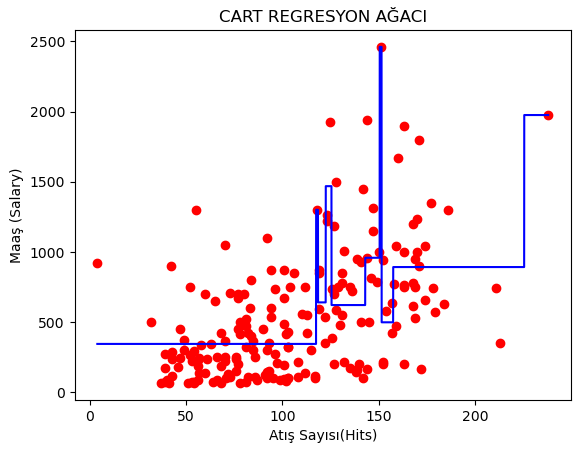

In [110]:
X_grid = np.arange(min(np.array(X_train)), max(np.array(X_train)), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1 ))

plt.scatter(X_train, y_train, color ='red')

plt.plot(X_grid, cart_model.predict(X_grid), color = 'blue')

plt.title('CART REGRESYON AĞACI')
plt.xlabel('Atış Sayısı(Hits)')
plt.ylabel('Maaş (Salary)');

In [121]:
# tek degıskenlı tahmin

In [112]:
cart_model.predict(X_test)[0:5]

array([621.96792308, 958.61111111, 621.96792308, 345.20115517,
       345.20115517])

In [113]:
y_pred = cart_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(486.34593105235456)

In [114]:
# tum degıskenlı tahmin

In [118]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [119]:
cart_model = DecisionTreeRegressor().fit(X_train, y_train)

In [120]:
y_pred = cart_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(436.8542932178285)

## 4.1. CART ALGORİTMASI MODEL TUNING

In [129]:
cart_model

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [153]:
cart_model = DecisionTreeRegressor(max_depth =5).fit(X_train, y_train)
y_pred = cart_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(435.5080020622849)

In [152]:
?cart_model

Type:        DecisionTreeRegressor
String form: DecisionTreeRegressor(max_depth=5)
File:        c:\users\hkoca\anaconda3\lib\site-packages\sklearn\tree\_classes.py
Docstring:  
A decision tree regressor.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"squared_error", "friedman_mse", "absolute_error",             "poisson"}, default="squared_error"
    The function to measure the quality of a split. Supported criteria
    are "squared_error" for the mean squared error, which is equal to
    variance reduction as feature selection criterion and minimizes the L2
    loss using the mean of each terminal node, "friedman_mse", which uses
    mean squared error with Friedman's improvement score for potential
    splits, "absolute_error" for the mean absolute error, which minimizes
    the L1 loss using the median of each terminal node, and "poisson" which
    uses reduction in the half mean Poisson deviance to find splits.

    .. versionadded:: 0.18
       Me

In [158]:
cart_params = {"max_depth": [2,3,4,5,10,20],
              "min_samples_split": [2,10,5,30,50,100]}

In [159]:
cart_model = DecisionTreeRegressor().fit(X_train, y_train)

In [160]:
cart_cv_model = GridSearchCV(cart_model, cart_params, cv=10).fit(X_train, y_train)

In [162]:
cart_cv_model.best_params_

{'max_depth': 10, 'min_samples_split': 50}

In [163]:
## final modeli

In [164]:
cart_tuned_model = DecisionTreeRegressor(max_depth=10, min_samples_split = 50).fit(X_train, y_train)

In [165]:
y_pred = cart_tuned_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(361.0876906511434)

## 5.RANDOM FORESTS (RASTGELE ORMANLAR) ALGORİTMASI MODEL VE TAHMİN

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import neighbors
from sklearn.svm import SVR

In [4]:
from warnings import filterwarnings
filterwarnings ('ignore')

In [3]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [5]:
rf_model = RandomForestRegressor(random_state = 42).fit(X_train, y_train)

In [6]:
rf_model

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
y_pred = rf_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(344.8191624908484)

In [8]:
#hocayla aynı sonucu yakalamak için deniyorum..
rf_model1 = RandomForestRegressor(random_state = 42, n_estimators=10).fit(X_train, y_train)

In [9]:
y_pred = rf_model1.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(375.1219133864713)

In [10]:
##hocada 373.04 küsürlü çıkmıştı. Demekki sürüm farkı ve buna bağlı parametre değerlerinden!!

## 5.1. RANDOM FORESTS ALGORİTMASI MODEL TUNING

In [29]:
rf_model = RandomForestRegressor(random_state = 42).fit(X_train, y_train)

In [30]:
rf_model

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
rf_params = {"max_depth": [5, 8, 10],
             "max_features": [2,5,10],
             "n_estimators": [200, 500, 1000, 2000],
             "min_samples_split": [2, 10, 80, 100]}

In [16]:
rf_cv_model = GridSearchCV(rf_model, rf_params, cv = 10, n_jobs = -1, verbose = 2).fit(X_train, y_train)

Fitting 10 folds for each of 144 candidates, totalling 1440 fits


In [32]:
rf_cv_model.best_params_

NameError: name 'rf_cv_model' is not defined

In [21]:
rf_model = RandomForestRegressor(random_state = 42,
                                 max_depth = 8,
                                 min_samples_split = 2,
                                 n_estimators = 200)
rf_tuned = rf_model.fit(X_train, y_train)

In [22]:
ft_tuned

,n_estimators,200
,criterion,'squared_error'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred = rf_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(342.15444403933856)

###  Değişken Önem Düzeyi

In [28]:
Importance = pd.DataFrame({'Importance': rf_tuned.feature_importances_*100},
                         index = X_train.columns)
Importance.sort_values(by = 'Importance',
                       axis = 0,
                       ascending = True).plot(kind = 'barh',
                                              color = 'r')
plt.xlabel('Variable Importance')
plt.gca().legend_ = None

NameError: name 'rf_tuned' is not defined

## 6. GRADIENT BOOSTING MACHINES (GBM) ALGORİTMASI MODEL VE TAHMİN

In [28]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [30]:
gbm_model = GradientBoostingRegressor().fit(X_train, y_train)

In [31]:
gbm_model

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [33]:
y_pred = gbm_model.predict(X_test)

In [34]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(352.1686885606803)

### 6.1. GRADIENT BOOSTING MACHINES (GBM) ALGORİTMASI MODEL TUNING

In [35]:
gbm_model = GradientBoostingRegressor().fit(X_train, y_train)

In [36]:
gbm_model

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [37]:
gbm_params = {"learning_rate" : [0.001, 0.1, 0.01],
              "max_depth": [3,5,8],
              "n_estimators": [100, 200, 500],
              "subsample": [1, 0.5, 0.8],
              "loss": ["ls", "lad", "quantile"]}

In [38]:
gbm_model = GradientBoostingRegressor().fit(X_train, y_train)

In [39]:
gbm_cv_mdoel = GridSearchCV(gbm_model,
                            gbm_params,
                            cv = 10,
                            n_jobs = -1,
                            verbose = 2).fit(X_train, y_train)

Fitting 10 folds for each of 243 candidates, totalling 2430 fits


In [40]:
gbm_cv_mdoel.best_params_

{'learning_rate': 0.1,
 'loss': 'quantile',
 'max_depth': 8,
 'n_estimators': 200,
 'subsample': 0.5}

In [47]:
gbm_tuned = GradientBoostingRegressor(learning_rate = 0.1,
                                      loss = "quantile",
                                      max_depth = 8,
                                      n_estimators = 200,
                                      subsample = 0.5).fit(X_train, y_train)

In [48]:
gbm_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(352.1686885606803)

### değişkenlerin önem düzeyi

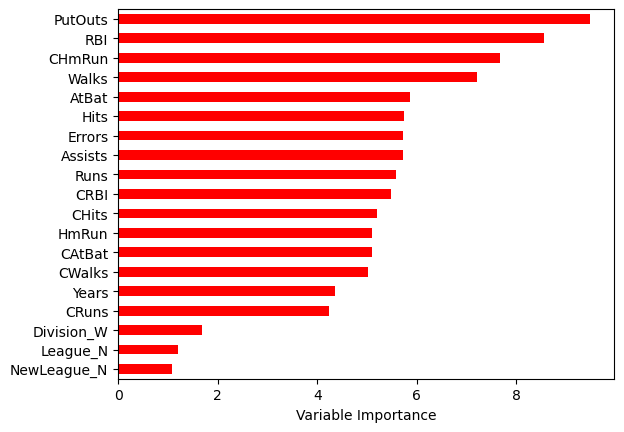

In [49]:
Importance = pd.DataFrame({'Importance': gbm_tuned.feature_importances_*100},
                         index = X_train.columns)
Importance.sort_values(by = 'Importance',
                       axis = 0,
                       ascending = True).plot(kind = 'barh',
                                              color = 'r')
plt.xlabel('Variable Importance')
plt.gca().legend_ = None

## 7. XGBOOST (eXtreme GRADIENT BOOSTING) ALGORİTMASI MODEL VE TAHMİN

In [63]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [6]:
!pip install xgboost

In [64]:
import xgboost
from xgboost import XGBRegressor

In [65]:
xgb = XGBRegressor().fit(X_train, y_train)

In [12]:
xgb

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [13]:
y_pred = xgb.predict(X_test)

In [14]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(366.3863437634965)

### 7.1 XGBOOST (eXtreme GRADIENT BOOSTING) ALGORİTMASI MODEL TUNING

In [15]:
xgb = XGBRegressor()

In [16]:
xgb

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [17]:
xgb_params = {"learning_rate": [0.1, 0.01, 0.5],
              "max_depth": [2, 3, 4, 5, 8],
              "n_estimators": [100, 200, 500, 1000],
              "colsample_bytree": [0.4, 0.7, 1]}

In [18]:
xgb_cv_model = GridSearchCV(xgb, xgb_params, cv = 10, n_jobs =-1, verbose = 2).fit(X_train,y_train)

Fitting 10 folds for each of 180 candidates, totalling 1800 fits


In [19]:
xgb_cv_model.best_params_

{'colsample_bytree': 0.4,
 'learning_rate': 0.1,
 'max_depth': 4,
 'n_estimators': 200}

In [21]:
xgb_tuned = XGBRegressor(xgb_cv_model = 0.4,
                         learning_rate = 0.1,
                         max_depth = 4,
                         n_estimators = 200).fit(X_train, y_train)

In [22]:
y_pred = xgb_tuned.predict(X_test)

In [24]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(360.8189910557665)

### değişkenlerin önem düzeyi

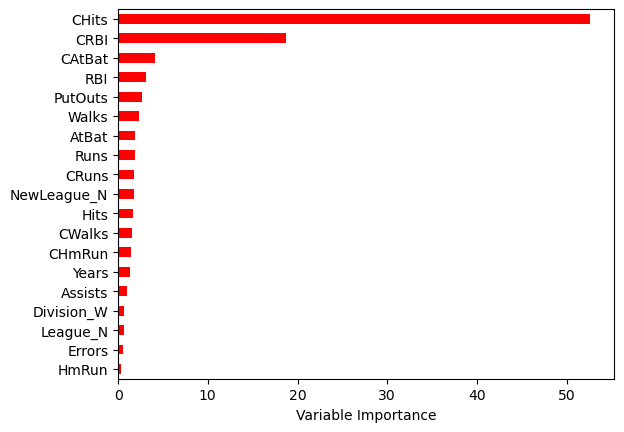

In [25]:
Importance = pd.DataFrame({'Importance': xgb_tuned.feature_importances_*100},
                         index = X_train.columns)
Importance.sort_values(by = 'Importance',
                       axis = 0,
                       ascending = True).plot(kind = 'barh',
                                              color = 'r')
plt.xlabel('Variable Importance')
plt.gca().legend_ = None

## 8.LIGHT GBM ALGORİTMASI MODEL VE TAHMİN

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import neighbors
from sklearn.svm import SVR

In [3]:
from warnings import filterwarnings
filterwarnings ('ignore')

In [4]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [27]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 2.3 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.6 MB/s  0:00:00


In [5]:
from lightgbm import LGBMRegressor

In [9]:
lgb_model = LGBMRegressor().fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 197, number of used features: 19
[LightGBM] [Info] Start training from score 543.483442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [10]:
lgb_model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [12]:
y_pred = lgb_model.predict(X_test)

In [13]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(363.8712087611089)

### 8.1 LIGHT GBM ALGORİTMASI MODEL TUNING

In [14]:
lgb_model = LGBMRegressor()
lgb_model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [15]:
lgbm_params = {"learning_rate": [0.01, 0.1, 0.5, 1],
               "n_estimators": [20, 40, 100, 500, 1000],
               "max_depth": [1,2,3,4,5,6,7,8,9,10]}

In [16]:
lgbm_cv_model = GridSearchCV(lgb_model, lgbm_params, cv = 10, n_jobs =-1, verbose=2).fit(X_train, y_train)

Fitting 10 folds for each of 200 candidates, totalling 2000 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 197, number of used features: 19
[LightGBM] [Info] Start training from score 543.483442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [18]:
lgbm_cv_model.best_params_

{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 20}

In [23]:
lgbm_tuned = LGBMRegressor(learning_rate = 0.1,
                          max_depth = 6,
                          n_estimators = 20).fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 197, number of used features: 19
[LightGBM] [Info] Start training from score 543.483442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [24]:
y_pred = lgbm_tuned.predict(X_test)

In [25]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(371.5044868943621)

### değişkenlerin önem düzeyi

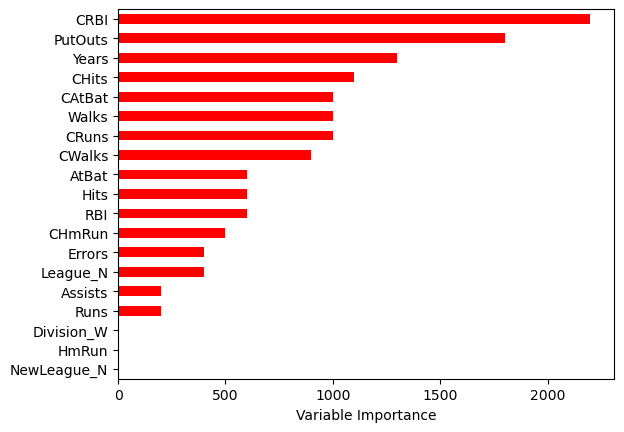

In [33]:
Importance = pd.DataFrame({'Importance': lgbm_tuned.feature_importances_*100},
                         index = X_train.columns)
Importance.sort_values(by = 'Importance',
                       axis = 0,
                       ascending = True).plot(kind = 'barh',
                                              color = 'r')
plt.xlabel('Variable Importance')
plt.gca().legend_ = None

## 9.CAT BOOST (CATEGORY BOOSTING) ALGORİTMASI MODEL VE TAHMİN

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import neighbors
from sklearn.svm import SVR

In [35]:
from warnings import filterwarnings
filterwarnings ('ignore')

In [36]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)
y = df["Salary"]
X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [37]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 2.3 MB/s eta 0:00:44
    --------------------------------------- 1.3/100.2 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 1.8/100.2 MB 2.6 MB/s eta 0:00:38
    --------------------------------------- 2.4/100.2 MB 2.6 MB/s eta 0:00:38
   - -------------------------------------- 2.9/100.2 MB 2.6 MB/s eta 0:00:37
   - -------------------------------------- 3.4/100.2 MB 2.6 MB/s eta 0:00:37
   - -------------------------------------- 3.9/100.2 MB 2.6 MB/s eta 0:00:37
   - -------------------------------------- 4.5/100.2 MB 2.7 MB/s eta 0:00:37
   -- ------------------------------------- 5.2/100.2 MB 2.7 MB/s eta 0:00:36
   -- ------------------------------------- 5.8/100.2 MB 2.7 MB/s eta 0:00:36
   -- ------------------------------------- 6.3/100.2 MB 2.7 MB/s eta 0:00:36


In [38]:
from catboost import CatBoostRegressor

In [39]:
catb_model = CatBoostRegressor().fit(X_train, y_train)

Learning rate set to 0.031674
0:	learn: 437.6430699	total: 132ms	remaining: 2m 11s
1:	learn: 431.3923642	total: 135ms	remaining: 1m 7s
2:	learn: 424.8820360	total: 140ms	remaining: 46.5s
3:	learn: 418.2514904	total: 143ms	remaining: 35.7s
4:	learn: 412.6394021	total: 152ms	remaining: 30.2s
5:	learn: 406.6247020	total: 155ms	remaining: 25.8s
6:	learn: 400.5321206	total: 159ms	remaining: 22.5s
7:	learn: 394.6683437	total: 163ms	remaining: 20.2s
8:	learn: 388.2496484	total: 166ms	remaining: 18.3s
9:	learn: 382.9448842	total: 171ms	remaining: 16.9s
10:	learn: 377.2600080	total: 175ms	remaining: 15.7s
11:	learn: 372.4829606	total: 179ms	remaining: 14.8s
12:	learn: 366.6823437	total: 183ms	remaining: 13.9s
13:	learn: 362.6076230	total: 187ms	remaining: 13.2s
14:	learn: 358.0107745	total: 193ms	remaining: 12.6s
15:	learn: 353.2802665	total: 197ms	remaining: 12.1s
16:	learn: 348.5646265	total: 201ms	remaining: 11.6s
17:	learn: 343.6407912	total: 204ms	remaining: 11.1s
18:	learn: 339.2363847	to

In [40]:
y_pred = catb_model.predict(X_test)

In [42]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(351.194631344607)

### 9.1 CATBOOST ALGORİTMASI MODEL TUNING

In [43]:
catb_params = {"iterations": [200, 500, 1000],
               "learning_rate":[0.01, 0.1],
               "depth": [3,6,8]}

In [44]:
catb_model = CatBoostRegressor()

In [45]:
catb_cv_model = GridSearchCV(catb_model, catb_params, cv = 5, n_jobs=-1, verbose=2).fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
0:	learn: 425.7900818	total: 2.07ms	remaining: 412ms
1:	learn: 404.8723520	total: 3.78ms	remaining: 375ms
2:	learn: 387.4057666	total: 5.37ms	remaining: 353ms
3:	learn: 372.2801584	total: 6.75ms	remaining: 331ms
4:	learn: 358.9204229	total: 7.81ms	remaining: 305ms
5:	learn: 347.0083933	total: 9.14ms	remaining: 296ms
6:	learn: 336.0130818	total: 10.8ms	remaining: 296ms
7:	learn: 324.3923300	total: 12.2ms	remaining: 294ms
8:	learn: 314.8690957	total: 14.1ms	remaining: 298ms
9:	learn: 308.5075563	total: 15.5ms	remaining: 294ms
10:	learn: 298.8587285	total: 16.8ms	remaining: 289ms
11:	learn: 294.7655438	total: 18.2ms	remaining: 285ms
12:	learn: 288.0697862	total: 19.5ms	remaining: 281ms
13:	learn: 282.6697154	total: 21ms	remaining: 279ms
14:	learn: 277.6121667	total: 22.4ms	remaining: 276ms
15:	learn: 273.4383979	total: 23.6ms	remaining: 272ms
16:	learn: 269.1556201	total: 25ms	remaining: 269ms
17:	learn: 264.8098704	total: 26.5m

In [46]:
catb_cv_model.best_params_

{'depth': 3, 'iterations': 200, 'learning_rate': 0.1}

In [47]:
catb_tuned = CatBoostRegressor(depth = 3,
                               iterations = 200,
                               learning_rate = 0.1).fit(X_train, y_train)

0:	learn: 425.7900818	total: 1.87ms	remaining: 373ms
1:	learn: 404.8723520	total: 4.9ms	remaining: 485ms
2:	learn: 387.4057666	total: 6.1ms	remaining: 400ms
3:	learn: 372.2801584	total: 7.51ms	remaining: 368ms
4:	learn: 358.9204229	total: 9.04ms	remaining: 352ms
5:	learn: 347.0083933	total: 10.3ms	remaining: 335ms
6:	learn: 336.0130818	total: 11.7ms	remaining: 323ms
7:	learn: 324.3923300	total: 13ms	remaining: 313ms
8:	learn: 314.8690957	total: 14.5ms	remaining: 308ms
9:	learn: 308.5075563	total: 15.9ms	remaining: 302ms
10:	learn: 298.8587285	total: 17.4ms	remaining: 298ms
11:	learn: 294.7655438	total: 18.7ms	remaining: 292ms
12:	learn: 288.0697862	total: 19.8ms	remaining: 285ms
13:	learn: 282.6697154	total: 21.2ms	remaining: 282ms
14:	learn: 277.6121667	total: 22.2ms	remaining: 273ms
15:	learn: 273.4383979	total: 23.6ms	remaining: 272ms
16:	learn: 269.1556201	total: 25.3ms	remaining: 273ms
17:	learn: 264.8098704	total: 26.9ms	remaining: 272ms
18:	learn: 261.6700768	total: 28.5ms	remai

In [49]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(351.194631344607)

### değişkenlerin önem düzeyi

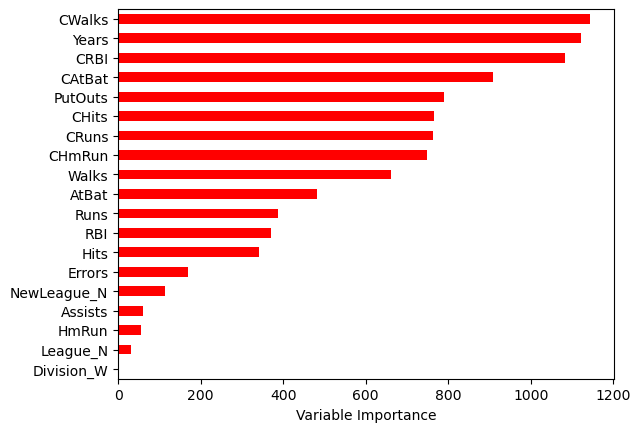

In [51]:
Importance = pd.DataFrame({'Importance': catb_tuned.feature_importances_*100},
                         index = X_train.columns)
Importance.sort_values(by = 'Importance',
                       axis = 0,
                       ascending = True).plot(kind = 'barh',
                                              color = 'r')
plt.xlabel('Variable Importance')
plt.gca().legend_ = None

## 10. MAKİNE ÖĞRENMESİ GÖREVLERİNİN OTOMATİKLEŞTİRİLMESİ

In [53]:
df = pd.read_csv("Hitters.csv")
df = df.dropna()
dms = pd.get_dummies(df[['League','Division','NewLeague']], dtype=int)

In [81]:
def compML(df, y, alg):
    #train-test ayrimi
    y = df[y]
    X_ = df.drop(['Salary','League','Division','NewLeague'], axis =1).astype('float64')
    X = pd.concat([X_, dms[['League_N','Division_W','NewLeague_N']]], axis=1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    #modelleme:
    model = alg().fit(X_train, y_train)
    y_pred = model.predict(X_test)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    model_ismi = alg.__name__
    print(model_ismi, "Modeli Test Hatası", RMSE)
   

In [82]:
compML(df, "Salary", LGBMRegressor)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 197, number of used features: 19
[LightGBM] [Info] Start training from score 543.483442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [83]:
compML(df, "Salary", SVR)

SVR Modeli Test Hatası 460.0032657244849


In [86]:
models = [LGBMRegressor,
          XGBRegressor,
          GradientBoostingRegressor,
          RandomForestRegressor,
          DecisionTreeRegressor,
          MLPRegressor,
          KNeighborsRegressor,
          SVR]

In [88]:
for i in models:
    compML(df, "Salary", i)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 197, number of used features: 19
[LightGBM] [Info] Start training from score 543.483442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 